In [2]:
using DifferentialEquations, PyPlot, Statistics, LaTeXStrings, PyCall, LinearAlgebra, FFTW

In [3]:
ENV["PYTHON"] = "C:\\Users\\admin\\Anaconda3\\envs\\data_vis\\python.exe"

LogNorm = pyimport("matplotlib.colors").LogNorm
cmap = pyimport("cmap")

lajolla = cmap.Colormap("crameri:lajolla").to_mpl();
balance = cmap.Colormap("cmocean:balance").to_mpl();
oslo = cmap.Colormap("crameri:oslo").to_mpl();
lipari = cmap.Colormap("crameri:lipari").to_mpl();
eclipse = cmap.Colormap("cmasher:eclipse").to_mpl();

# Configure LaTeX rendering and fonts
PyPlot.matplotlib[:rc]("text", usetex=true)
PyPlot.matplotlib[:rc]("font", family="serif", serif=["mathpazo"], size=18)  # Base font size
PyPlot.matplotlib[:rc]("axes", titlesize=30)             # Axis title
PyPlot.matplotlib[:rc]("axes", labelsize=30)             # Axis labels
PyPlot.matplotlib[:rc]("xtick", labelsize=24)            # X-ticks
PyPlot.matplotlib[:rc]("ytick", labelsize=24)            # Y-ticks
PyPlot.matplotlib[:rc]("legend", fontsize=24)            # Legend
PyPlot.matplotlib[:rc]("figure", titlesize=24)           # Figure title
PyPlot.svg(true)
# LaTeX preamble packages
PyPlot.matplotlib[:rc]("text.latex", preamble="\\usepackage{amsmath}\\usepackage{amsfonts}\\usepackage{amssymb}\\usepackage{lmodern}")

In [4]:
# Define the system of ODEs
function coupled_eqs!(du, u, p, t)
    Δ1, Δ2, g, φ, Δ, κ, η= p
    s1x, s1y, s1z, s2x, s2y, s2z, α_re, α_im = u

    α = α_re + im * α_im
    α_star = conj(α)
    exp_iφ = cos(φ) + im * sin(φ)
    exp_minus_iφ = conj(exp_iφ)

    du[1] = Δ1 * s1y + im* g * s1z * (α - α_star) + γ*s1x*s1z # s1x_dot
    du[2] = -Δ1 * s1x - g * s1z * (α_star + α) + γ*s1y*s1z  # s1y_dot
    du[3] = -im* g * s1x * (α - α_star) + g * s1y * (α_star + α) - γ* (s1x*s1x + s1y*s1y) # s1z_dot

    du[4] = Δ2 * s2y + im* g * s2z * (exp_iφ * α - exp_minus_iφ * α_star) + γ*s2x*s2z # s2x_dot
    du[5] = -Δ2 * s2x - g * s2z * (exp_minus_iφ * α_star + exp_iφ * α) + γ*s2y*s2z # s2y_dot
    du[6] = -im* g * s2x * (exp_iφ * α - exp_minus_iφ * α_star) + g * s2y * (exp_minus_iφ * α_star + exp_iφ * α) - γ* (s2x*s2x + s2y*s2y) # s2z_dot

    dα = (Δ * im - κ / 2) * α - (g / 2) * (im * (s1x + exp_minus_iφ * s2x) + (s1y + exp_minus_iφ * s2y)) + η
    du[7] = real(dα)  # Re(α_dot)
    du[8] = imag(dα)  # Im(α_dot)
end

# Define the system of ODEs WHEN CAVITY IS ELIMINATED
function spin_only_coupled_eqs!(du, u, p, t)
    Δ1, Δ2, g, φ, Δ, κ, η = p
    s1x, s1y, s1z, s2x, s2y, s2z = u

    # Derived parameters
    K = κ / 2
    Δ_plus = Δ * cos(φ) + K * sin(φ)
    Δ_minus = Δ * cos(φ) - K * sin(φ)
    K_plus = K * cos(φ) + Δ * sin(φ)
    K_minus = K * cos(φ) - Δ * sin(φ)
    𝒥 = g^2 / (Δ^2 + K^2)  # 𝒥 = g²/(Δ² + (κ/2)²)

    # Equations for s1x, s1y, s1z, s2x, s2y, s2z
    du[1] = Δ1 * s1y + s1z * 𝒥 * (Δ * s1y + K * s1x + K_plus * s2x + Δ_minus * s2y - 2 * Δ * η / g) 
    du[2] = -Δ1 * s1x + s1z * 𝒥 * (-Δ * s1x + K * s1y - Δ_minus * s2x + K_plus * s2y - 2 * K * η / g) 
    du[3] = -𝒥 * (
        -2 * η / g * (K * s1y + Δ * s1x) +
        K * (s1x^2 + s1y^2) +
        K_plus * s1x * s2x +
        Δ_minus * s1x * s2y -
        Δ_minus * s1y * s2x +
        K_plus * s1y * s2y
    ) 
    du[4] = Δ2 * s2y + s2z * 𝒥 * (Δ * s2y + K * s2x + K_minus * s1x + Δ_plus * s1y - 2 * Δ_plus * η / g)
    du[5] = -Δ2 * s2x + s2z * 𝒥 * (-Δ * s2x + K * s2y - Δ_plus * s1x + K_minus * s1y - 2 * K_minus * η / g) 
    du[6] = -𝒥 * (
        -2 * η / g * (K_minus * s2y + Δ_plus * s2x) +
        K * (s2x^2 + s2y^2) +
        K_minus * s2x * s1x +
        Δ_plus * s2x * s1y -
        Δ_plus * s2y * s1x +
        K_minus * s2y * s1y 
    ) 
end


spin_only_coupled_eqs! (generic function with 1 method)

In [5]:
# Run sample simulation

Δ = 0.0
ϕ = 0

κ = 1.0
g = 0.1*κ
η = 1.5*g
Δ1 = 0.1*g
Δ2 = 0.1*g

γ = 0*g

# Time steps
Gamma = 2*g^2/κ
tend = 150/Gamma
t_list = range(0.0, tend, length=200)

sp = 0
u0c = [sqrt(1-sp^2), 0, -sp, sqrt(1-sp^2), 0, -sp, 0, 0];
params = (Δ1, Δ2, g, ϕ, Δ, κ, η, γ)

prob = ODEProblem(coupled_eqs!, u0c, (0.0, tend), params)
sol = solve(prob, Tsit5(), saveat=t_list, reltol=1e-6, abstol=1e-9, maxiters=1e10)

# Extract data from time steps 6000 to 10000
# range_idx = 60000:100000

ephi = exp(-im*ϕ)
# s_α_sq  = @. abs2(( ( g/2 * (im*(sol[1, range_idx] + ephi*sol[4, range_idx]) + (sol[2, range_idx] + ephi*sol[5, range_idx])) - η ) / (im * Δ - κ/2)));
sx1 = sol[1, :];
sy1 = sol[2, :];
sz1 = sol[3, :];
sx2 = sol[4, :];
sy2 = sol[5, :];
sz2 = sol[6, :];
α_re = sol[7,:];
α_im = sol[8,:];
α = α_re + im * α_im;
adaga = α .* conj(α);


theta1 = atan.(sy1, sx1);
theta2 = atan.(sy2, sx2);
r1 = sqrt.(sx1.^2 + sy1.^2);
r2 = sqrt.(sx2.^2 + sy2.^2);

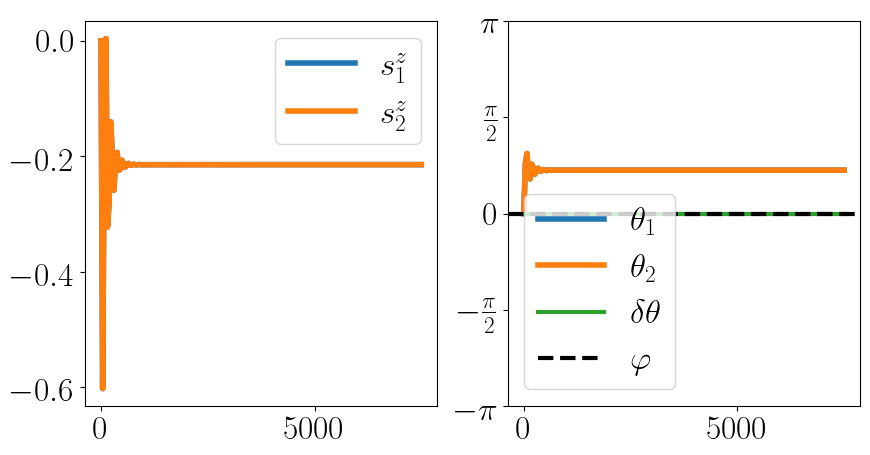

In [268]:
fig, axs = subplots(1, 2, figsize=(10, 5))

s1m = sx1 .+ im .* sy1
s2m = sx2 .+ im .* sy2


axs[1].plot(sol.t, sz1, lw=4, label = L"s_1^z")
axs[1].plot(sol.t, sz2, lw=4, label = L"s_2^z")
# axs[1].plot(sol.t, r1, lw=4, label = L"r_1")
# axs[1].plot(sol.t, r2, lw=4, label = L"r_2")
# axs[1].set_ylim(-0.4, -0.35)
axs[1].legend()
axs[2].plot(sol.t, theta1, lw=4, label = L"\theta_1")
axs[2].plot(sol.t, theta2, lw=4, label = L"\theta_2")
axs[2].plot(sol.t, (theta2-theta1), lw=3, label= L"\delta\theta")
axs[2].set_yticks([-pi, -pi/2, 0, pi/2, pi], [L"-\pi", L"-\frac{\pi}{2}", L"0", L"\frac{\pi}{2}", L"\pi"])
axs[2].axhline(ϕ, color="black", lw=3, ls="--",label=L"\varphi")

axs[2].legend()
display(fig)

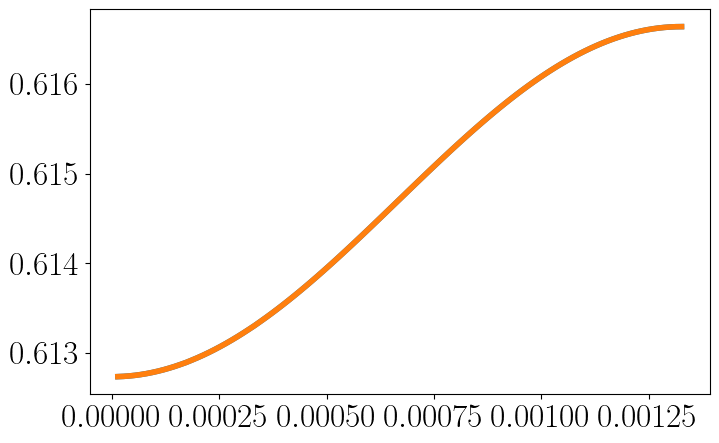

In [233]:
# plot fft of s1z and sz2

Fs = 1/(sol.t[2]-sol.t[1])
N = length(sol.t)
f1 = abs.(fft(sz1))
f2 = abs.(fft(sz2))
frequencies = Fs * (1:(N ÷ 2)) / N
fig, ax = subplots(1, 1, figsize=(8, 5))
ax.plot(frequencies, f1[2:N ÷ 2 + 1], lw=4, label = L"1")
ax.plot(frequencies, f2[2:N ÷ 2 + 1], lw=4, label = L"2|")
# ax.set_xlim(0.0001, 0.02*g)
# ax.set_ylim(0, 50)
display(fig)

In [601]:
using DelimitedFiles

# Save sz1 to a text file
#writedlm("../finsize_data/mf_data4s1.txt", sz1)
#writedlm("../finsize_data/mf_data4s2.txt", sz2)

In [282]:
# Fixed parameters

g, κ = 0.1, 1.0
Δ = 0.0
Δ1, Δ2 = 0.1g, 0.1g
# Time steps
tend = 1000/g
t_list = range(0.0, tend, length=100001)

# Initial conditions
u0c = [1, 0.0, 0, 1, 0.0, 0, 0, 0];
u0s = [1, 0, 0.0, 1, 0, 0.0];

In [283]:
 
# Parameter ranges
η_vals = range(0.0*g, 1.5 * g, length=51)
φ_vals = range(-π, π, length=51)


# Store results
avg_alpha_sq = zeros(length(φ_vals), length(η_vals))
s_avg_alpha_sq = zeros(length(φ_vals), length(η_vals))
avg_sz1 = zeros(length(φ_vals), length(η_vals))
avg_sz2 = zeros(length(φ_vals), length(η_vals))
var_sz1 = zeros(length(φ_vals), length(η_vals))
var_sz2 = zeros(length(φ_vals), length(η_vals))
var_sx1 = zeros(length(φ_vals), length(η_vals))
var_sx2 = zeros(length(φ_vals), length(η_vals))
var_sy1 = zeros(length(φ_vals), length(η_vals))
var_sy2 = zeros(length(φ_vals), length(η_vals))

var_theta1 = zeros(length(φ_vals), length(η_vals))
var_theta2 = zeros(length(φ_vals), length(η_vals))

s1_2 = zeros(length(φ_vals), length(η_vals))
s2_2 = zeros(length(φ_vals), length(η_vals))

spin_corr = zeros(length(φ_vals), length(η_vals))

# Solve ODE for each η and φ
for (i, φ) in enumerate(φ_vals)
# for (i, Δ) in enumerate(Δ_vals)
    ephi = exp(-im*φ)
    for (j, η) in enumerate(η_vals)
    
        params = (Δ1, Δ2, g, φ, Δ, κ, η)
        prob = ODEProblem(coupled_eqs!, u0c, (0.0, tend), params)
        sol = solve(prob, Tsit5(), saveat=t_list, reltol=1e-6, abstol=1e-9)

        # Extract data from time steps 6000 to 10000
        range_idx = 6000:10000
        
        α_sq = sol[7, range_idx].^2 + sol[8, range_idx].^2  # |α|²
        #s_α_sq  = @. abs2(( ( g/2 * (im*(sol[1, range_idx] + ephi*sol[4, range_idx]) + (sol[2, range_idx] + ephi*sol[5, range_idx])) - η ) / (im * Δ - κ/2)))
        sx1 = sol[1, range_idx]
        sy1 = sol[2, range_idx]
        sz1 = sol[3, range_idx]
        sx2 = sol[4, range_idx]
        sy2 = sol[5, range_idx]
        sz2 = sol[6, range_idx]
        sz1_sz2 = sol[3, range_idx] .* sol[6, range_idx]

        # Spin length
        s1_2[i,j]= mean(sol[1, range_idx].^2 + sol[2, range_idx].^2 + sol[3, range_idx].^2)
        s2_2[i,j]= mean(sol[4, range_idx].^2 + sol[5, range_idx].^2 + sol[6, range_idx].^2)
        
        # Cavity and spin observables
        avg_alpha_sq[i, j] = mean(α_sq)
        #s_avg_alpha_sq[i,j] = mean(s_α_sq)
        var_sz1[i, j] = var(sz1)
        var_sz2[i, j] = var(sz2)
        var_sx1[i, j] = var(sx1)
        var_sx2[i, j] = var(sx2)
        var_sy1[i, j] = var(sy1)
        var_sy2[i, j] = var(sy2)
        avg_sz1[i, j] = mean(sz1)
        avg_sz2[i, j] = mean(sz2)

        # Spin angles
        theta1 = atan.(sy1, sx1)
        theta2 = atan.(sy2, sx2)
        var_theta1[i, j] = var(theta1)
        var_theta2[i, j] = var(theta2)
        
    end
end

In [59]:
using DelimitedFiles

# writedlm("vars_sz1_nodet.txt", var_sz1)
# writedlm("vars_sz2_nodet.txt", var_sz2)

#writedlm("vars_sz1_wdet.txt", var_sz1)
#writedlm("vars_sz2_wdet.txt", var_sz2)

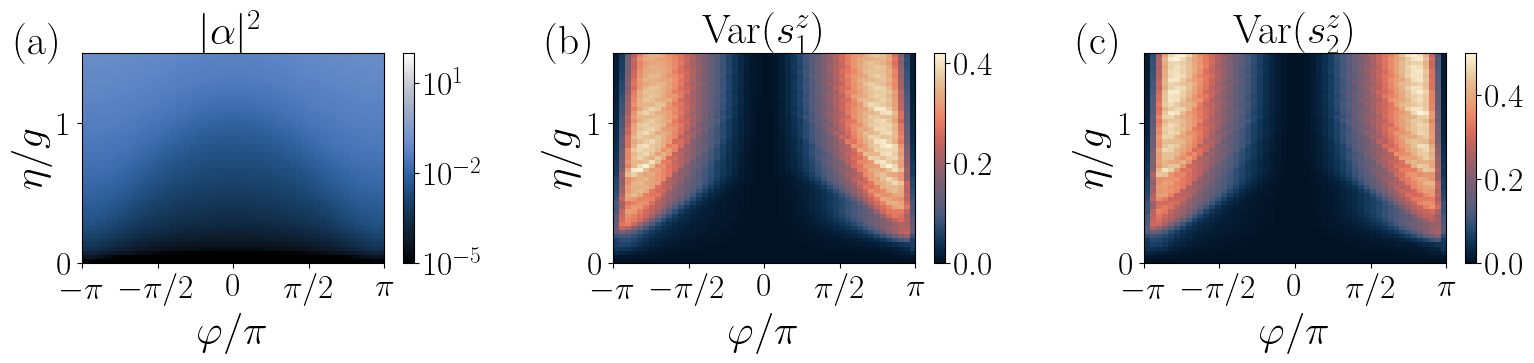

In [284]:
x = φ_vals./π
y = η_vals./g



xtick_locs = [-1.0, -0.5, 0.0, 0.5, 1.0]  # x = φ/π
xtick_labels = [L"-\pi", L"-\pi/2", L"0", L"\pi/2", L"\pi"]


fig, axs = subplots(1, 3, figsize=(16, 4))

# p1: Plot log10(<|α|²>)
im1 = axs[1].imshow(avg_alpha_sq',
                     extent=(minimum(x), maximum(x), minimum(y), maximum(y)),
                     origin="lower",
                     aspect="auto",
                     cmap=oslo,         # Use your defined colormap
                     norm=LogNorm(vmin=1e-5, vmax=1e2))     # Color limits
axs[1].set_ylabel(L"\eta/g")
axs[1].set_xlabel(L"\varphi/\pi")
axs[1].set_title(L"|\alpha|^2")
axs[1].set_xticks(xtick_locs)
axs[1].set_xticklabels(xtick_labels)
colorbar(im1, ax=axs[1])
axs[1].text(-0.22, 1.15, "(a)", transform=axs[1].transAxes, fontsize=30, fontweight="bold", va="top", ha="left")
# p2: Plot Var s₁ᶻ
im2 = axs[2].imshow(var_sz1',
                     extent=(minimum(x), maximum(x), minimum(y), maximum(y)),
                     origin="lower",
                     aspect="auto",
                     cmap=lipari,        # Use your defined colormap
                     vmin=0, vmax=maximum(var_sz1))    # Color limits
axs[2].set_ylabel(L"\eta/g")
axs[2].set_xlabel(L"\varphi/\pi")
axs[2].set_title(L"\mathrm{Var}(s_1^z)")
axs[2].set_xticks(xtick_locs)
axs[2].set_xticklabels(xtick_labels)
colorbar(im2, ax=axs[2])
axs[2].text(-0.22, 1.15, "(b)", transform=axs[2].transAxes, fontsize=30, fontweight="bold", va="top", ha="left")
# p3: Plot Var s₂ᶻ
im3 = axs[3].imshow(var_sz2',
                     extent=(minimum(x), maximum(x), minimum(y), maximum(y)),
                     origin="lower",
                     aspect="auto",
                     cmap=lipari,       
                     vmin=0, vmax=maximum(var_sz2))    
axs[3].set_ylabel(L"\eta/g")
axs[3].set_xlabel(L"\varphi/\pi")
axs[3].set_title(L"\mathrm{Var}(s_2^z)")
axs[3].set_xticks(xtick_locs)
axs[3].set_xticklabels(xtick_labels)
colorbar(im3, ax=axs[3])
axs[3].text(-0.22, 1.15, "(c)", transform=axs[3].transAxes, fontsize=30, fontweight="bold", va="top", ha="left")

# Adjust layout for better spacing
tight_layout()

# Save the figure as a PDF file
# plt.savefig("phased_g,kap=01,1_Del=0_Ds=01.pdf", format="pdf", bbox_inches="tight")

display(fig)

In [ ]:
x = φ_vals./π
y = η_vals./g

xtick_locs = [-1.0, -0.5, 0.0, 0.5, 1.0]  # x = φ/π
xtick_labels = [L"-\pi", L"-\pi/2", L"0", L"\pi/2", L"\pi"]


fig, axs = subplots(1, 2, figsize=(9, 3))

# p2: Plot avg s₁ᶻ
im2 = axs[1].imshow(avg_sz1',
                     extent=(minimum(x), maximum(x), minimum(y), maximum(y)),
                     origin="lower",
                     aspect="auto",
                     cmap=lipari,        # Use your defined colormap
                     vmin=-1, vmax=1)    # Color limits
axs[1].set_ylabel(L"\eta/g")
axs[1].set_xlabel(L"\varphi/\pi")
axs[1].set_title(L"\langle s_1^z\rangle")
axs[1].set_xticks(xtick_locs)
axs[1].set_xticklabels(xtick_labels)
colorbar(im2, ax=axs[1])
axs[1].text(-0.22, 1.15, "(a)", transform=axs[1].transAxes, fontsize=22, fontweight="bold", va="top", ha="left")
# p3: Plot avg s₂ᶻ
im3 = axs[2].imshow(avg_sz2',
                     extent=(minimum(x), maximum(x), minimum(y), maximum(y)),
                     origin="lower",
                     aspect="auto",
                     cmap=lipari,       
                     vmin=-1, vmax=1)    
axs[2].set_ylabel(L"\eta/g")
axs[2].set_xlabel(L"\varphi/\pi")
axs[2].set_title(L"\langle s_2^z\rangle")
axs[2].set_xticks(xtick_locs)
axs[2].set_xticklabels(xtick_labels)
colorbar(im3, ax=axs[2])
axs[2].text(-0.22, 1.15, "(b)", transform=axs[2].transAxes, fontsize=22, fontweight="bold", va="top", ha="left")

# Adjust layout for better spacing
tight_layout()

# Save the figure as a PDF file
#plt.savefig("mz_phased_g02_Delta02.pdf", format="pdf", bbox_inches="tight")

display(fig)

In [ ]:
x = φ_vals./π
y = η_vals./g

xtick_locs = [-1.0, -0.5, 0.0, 0.5, 1.0]  # x = φ/π
xtick_labels = [L"-\pi", L"-\pi/2", L"0", L"\pi/2", L"\pi"]


fig, axs = subplots(1, 4, figsize=(15, 3))


im1 = axs[1].imshow(var_sx1',
                     extent=(minimum(x), maximum(x), minimum(y), maximum(y)),
                     origin="lower",
                     aspect="auto",
                     cmap=lipari,        # Use your defined colormap
                     vmin=0, vmax=0.5)    # Color limits
axs[1].set_ylabel(L"\eta/g")
axs[1].set_xlabel(L"\varphi/\pi")
axs[1].set_title(L"\mathrm{Var}(s_1^x)")
axs[1].set_xticks(xtick_locs)
axs[1].set_xticklabels(xtick_labels)
colorbar(im1, ax=axs[1])
axs[1].text(-0.22, 1.15, "(a)", transform=axs[1].transAxes, fontsize=22, fontweight="bold", va="top", ha="left")
# p3: Plot avg s₂ᶻ
im2 = axs[2].imshow(var_sx2',
                     extent=(minimum(x), maximum(x), minimum(y), maximum(y)),
                     origin="lower",
                     aspect="auto",
                     cmap=lipari,       
                     vmin=0, vmax=0.5)    
axs[2].set_ylabel(L"\eta/g")
axs[2].set_xlabel(L"\varphi/\pi")
axs[2].set_title(L"\mathrm{Var}(s_2^x)")
axs[2].set_xticks(xtick_locs)
axs[2].set_xticklabels(xtick_labels)
colorbar(im2, ax=axs[2])
axs[2].text(-0.22, 1.15, "(b)", transform=axs[2].transAxes, fontsize=22, fontweight="bold", va="top", ha="left")

im3 = axs[3].imshow(var_sy1',
                     extent=(minimum(x), maximum(x), minimum(y), maximum(y)),
                     origin="lower",
                     aspect="auto",
                     cmap=lipari,       
                     vmin=0, vmax=0.5)    
axs[3].set_ylabel(L"\eta/g")
axs[3].set_xlabel(L"\varphi/\pi")
axs[3].set_title(L"\mathrm{Var}(s_1^y)")
axs[3].set_xticks(xtick_locs)
axs[3].set_xticklabels(xtick_labels)
colorbar(im3, ax=axs[3])
axs[3].text(-0.22, 1.15, "(c)", transform=axs[3].transAxes, fontsize=22, fontweight="bold", va="top", ha="left")


im4 = axs[4].imshow(var_sy2',
                     extent=(minimum(x), maximum(x), minimum(y), maximum(y)),
                     origin="lower",
                     aspect="auto",
                     cmap=lipari,      
                     vmin=0, vmax=0.5)    
axs[4].set_ylabel(L"\eta/g")
axs[4].set_xlabel(L"\varphi/\pi")
axs[4].set_title(L"\mathrm{Var}(s_2^y)")
axs[4].set_xticks(xtick_locs)
axs[4].set_xticklabels(xtick_labels)
colorbar(im4, ax=axs[4])
axs[4].text(-0.22, 1.15, "(d)", transform=axs[4].transAxes, fontsize=22, fontweight="bold", va="top", ha="left")
tight_layout()


display(fig)

In [ ]:
Δ1, Δ2 = 0, 0
g, κ = 0.1, 1.0
Δ = 0.0
φ = 3pi/2
η = 0.8g
p = [Δ1, Δ2, g, φ, Δ, κ, η]
tend = 1000000
t_list = range(0.0, tend, length=2000001)
tspan = (0.0, tend)

u0c = [1, 0.0, 0, 1,0, 0, 0, 0];

# Define and solve the ODE problem
prob = ODEProblem(coupled_eqs!, u0c, tspan, p)
sol = solve(prob, Tsit5(), abstol=1e-9,reltol=1e-9, saveat=t_list, maxiters=1e12)

# Extract spin components
s1x = sol[1, :]
s1y = sol[2, :]
s1z = sol[3, :]
s2x = sol[4, :]
s2y = sol[5, :]
s2z = sol[6, :]
αr = sol[7, :]
αi = sol[8, :]

# s_α  = @. ( ( g/2 * (im*(sol[1, :] + exp(-im*φ)*sol[4, :]) + (sol[2, :] + exp(-im*φ)*sol[5, :])) - η ) / (im * Δ - κ/2))
# s_αr = real(s_α)
# s_αi = imag(s_α)

# a_phase = atan.(s_αi, s_αr)
# adaga = abs2.(s_α)

a_phase = atan.(αi, αr)
adaga = αr.^2 + αi.^2

spin1_length = s1x.^2 .+ s1y.^2 .+ s1z.^2;
spin2_length = s2x.^2 .+ s2y.^2 .+ s2z.^2;


color1 = "#D81B60"  # Deep pink
color2 = "#1E88E5"  # Vibrant blue
color3 = "#FFC107"  # Warm gold
color4 = "#004D40"  # Deep teal
crimson = "#DC143C"  # Crimson color

fig, axs = subplots(1, 3, figsize=(12, 4))

# p1
p1 = axs[1].plot(t_list,s1z, lw=2.5, color = color2)   
axs[1].set_xscale("log") 
axs[1].set_xlabel(L"t/\kappa")
axs[1].set_ylabel(L"m_1^z")
axs[1].set_ylim(-1.1,1.1)
axs[1].text(-0.22, 1.15, "(a)", transform=axs[1].transAxes, fontsize=22, fontweight="bold", va="top", ha="left")
# p2
p2 = axs[2].plot(t_list,s2z, lw=2.5, color = crimson)    
axs[2].set_xscale("log") 
axs[2].set_xlabel(L"t/\kappa")
axs[2].set_ylabel(L"m_2^z")
axs[2].set_ylim(-1.1,1.1)
axs[2].text(-0.22, 1.15, "(b)", transform=axs[2].transAxes, fontsize=22, fontweight="bold", va="top", ha="left")

p3 = axs[3].plot(t_list,a_phase, lw=2.5, label=L"\phi_c", color =color3 )  
p3 = axs[3].plot(t_list,adaga, lw=2.5, label=L"|\alpha|^2", color = color4)  
axs[3].set_xscale("log") 
axs[3].set_xlabel(L"t/\kappa")
axs[3].set_ylabel("Cavity")
axs[3].text(-0.22, 1.15, "(c)", transform=axs[3].transAxes, fontsize=22, fontweight="bold", va="top", ha="left")
axs[3].legend()
# Adjust layout for better spacing
tight_layout()

#plt.savefig("mz_cavity_dyns_sym2.pdf", format="pdf", bbox_inches="tight")
display(fig)


Plotting frequency maxima

In [6]:
# Fixed parameters (as before)
g, κ  = 0.1, 1.0
Δ1, Δ2 = 0.1g, 0.1g
Δ    = 0.0*g
#η = 0.4*g 

δ_vals = range(-1g, 1g, length=51)
η_vals = range(0.1*g, 1.5*g, length=51)
φ_vals = range(-π+0.02, π-0.02, length=50)

# Time grid
tend  = 10000 / g
t_list = range(0.0, tend, length = 10_001)
dt     = t_list[2] - t_list[1]      # uniform timestep

# Initial state
u0c = [1, 0, 0, 1, 0, 0, 0, 0]

# Parameter ranges
# η_vals = range(0.001 * g, 1.5 * g, length = 201)
# φ_vals = range(-π, π, length = 201)

# “Steady‐state” index range: second half of the time‐series
# (divide the total number of points by 2; here length(t_list)=100001,
# so index ∼ 50001:100001)
steady_idx = collect(div(length(t_list), 2) : length(t_list))

# # Preallocate arrays for the peak‐frequency of sz1 and sz2:
# #   - dims: (length(φ_vals), length(η_vals))
fpeak_sz1 = zeros(Float64, length(φ_vals), length(δ_vals))
fpeak_sz2 = zeros(Float64, length(φ_vals), length(δ_vals))

fpeak_th1 = zeros(Float64, length(φ_vals), length(η_vals))
fpeak_th2 = zeros(Float64, length(φ_vals), length(η_vals))

mean_sz1 = zeros(Float64, length(φ_vals), length(η_vals))
mean_sz2 = zeros(Float64, length(φ_vals), length(η_vals))

# Main double loop
for (iφ, φ) in enumerate(φ_vals)
    for (iη, η) in enumerate(η_vals)
        # (1) Build & solve the ODEProblem
        params = (Δ1, Δ2, g, φ, Δ, κ, η)
        prob = ODEProblem(coupled_eqs!, u0c, (0.0, tend), params)
        sol  = solve(prob, Tsit5(); saveat = t_list,
                              reltol = 1e-6, abstol = 1e-9)


        sz1_window = (sol[3, steady_idx])
        sz2_window = (sol[6, steady_idx])
        theta1_window = atan.(sol[2, steady_idx], sol[1, steady_idx])
        theta2_window = atan.(sol[5, steady_idx], sol[4, steady_idx])

        m1 = mean(sz1_window); mean_sz1[iφ, iη] = m1
        m2 = mean(sz2_window); mean_sz2[iφ, iη] = m2

        # (3) FFT of each window
        fft_sz1 = fft(sz1_window)
        fft_sz2 = fft(sz2_window)
        fft_th1 = fft(theta1_window)
        fft_th2 = fft(theta2_window)


        # (4) Compute frequency‐axis parameters
        N = length(sz1_window)        # number of points in steady window
        df = 1.0 / (N * dt)           # frequency resolution
        Nhalf = div(N, 2)             # positive‐frequency bins are 1..Nhalf
                                      # (bin‐1 is DC, bins 2..Nhalf are f>0)

        #  (A) Discard the DC bin by zeroing it out:
        amp1 = abs.(fft_sz1)
        amp2 = abs.(fft_sz2)

        ampth1 = abs.(fft_th1)
        ampth2 = abs.(fft_th2)


        pos_range = 2 : Nhalf

        #  Find the index (within pos_range) where amplitude is maximum
        #     Note: `argmax(amp1[pos_range])` returns a position in pos_range
        fpeak_sz1[iφ, iη] = argmax(amp1[pos_range])
        fpeak_sz2[iφ, iη] = argmax(amp2[pos_range])

        fpeak_th1[iφ, iη] = argmax(ampth1[pos_range])
        fpeak_th2[iφ, iη] = argmax(ampth2[pos_range])
    end
end


In [191]:
function reject_outliers(data, m = 10)
    """ 
    Helper function to reject outliers from multidimensional arrays. 
    For a given array, computes median, and then median absolute deviation (MAD). Returns the same array, with outliers
    replaced by 0. An outlier is defined as falling more than m*MAD away from the median. 

    """
    d = abs.(data .- median(data))
    mdev = median(d)
    s = d ./ (mdev + eps())   
    # outliers replaced by 0
    return ifelse.(s .< m, data, 0)
end

reject_outliers (generic function with 2 methods)

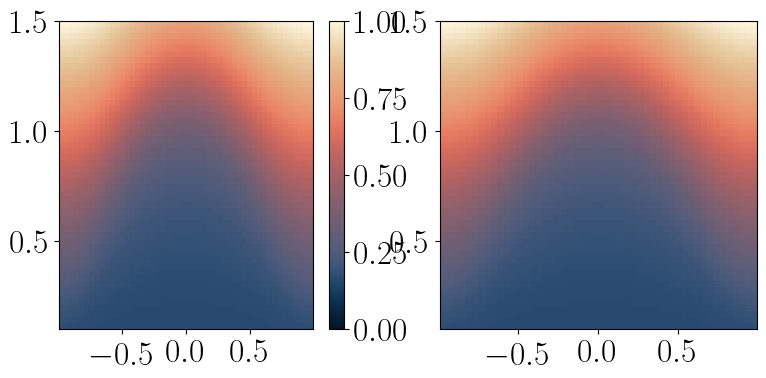

In [196]:
data_max = maximum(reject_outliers(fpeak_sz1))

fig, ax = subplots(1, 2, figsize=(9, 4))
x = φ_vals./π
y = η_vals./g
# x = δ_vals./g
im1 = ax[1].imshow((fpeak_sz1 .* 1/maximum(fpeak_sz1))' ,
                     extent=(minimum(x), maximum(x), minimum(y), maximum(y)),
                     origin="lower",
                     aspect="auto", cmap=lipari, vmin=0, vmax=1)        
im2 = ax[2].imshow((fpeak_sz2 .* 1/maximum(fpeak_sz2))',
                     extent=(minimum(x), maximum(x), minimum(y), maximum(y)),
                     origin="lower",
                     aspect="auto", cmap=lipari, vmin=0, vmax=1)
colorbar(im1, ax=ax[1])
# colorbar(im2, ax=ax[2])
display(fig)

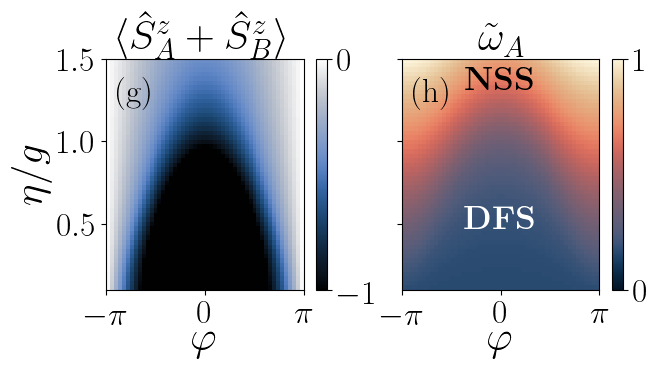

In [62]:
#plot magnetizations
fig, ax = subplots(1, 2, figsize=(7, 3))
x = φ_vals./π
y = η_vals./g
# x = δ_vals./g
im1 = ax[1].imshow( (mean_sz1 + mean_sz2)',
                     extent=(minimum(x), maximum(x), minimum(y), maximum(y)),
                     origin="lower",
                     aspect="auto", cmap=oslo, vmin=-1, vmax=0)        
im2 = ax[2].imshow((fpeak_sz1 .* 1/maximum(fpeak_sz1))',
                     extent=(minimum(x), maximum(x), minimum(y), maximum(y)),
                     origin="lower",
                     aspect="auto", cmap=lipari, vmin=0, vmax=1)
ax[1].set_xticks([x[1], 0, x[end]], [L"-\pi", 0, L"\pi"])
ax[1].set_title(L"\langle \hat{S}^z_A+\hat{S}^z_B\rangle")
#ax[2].set_title(L"\mathrm{argmax}(\mathcal{F}(\langle \hat{S}^z_A\rangle))")
ax[2].set_title(L"\tilde{\omega}_A")
ax[2].set_yticklabels("")

ax[2].set_xticks([x[1], 0, x[end]], [L"-\pi", 0, L"\pi"])
ax[1].set_ylabel(L"\eta/g")
ax[1].set_xlabel(L"\varphi", labelpad=-5)
ax[2].set_xlabel(L"\varphi",labelpad=-5)
ax[2].text(
    0.5, 0.3, L"\textbf{DFS}",
    transform=ax[2].transAxes,
    ha="center", va="center",
    color="white", fontsize=24
)

ax[2].text(
    0.5, 0.9, L"\textbf{NSS}",
    transform=ax[2].transAxes,
    ha="center", va="center",
    color="black", fontsize=24
)

# ax[2].text(
#     0.5, 0.25, L"\mathrm{\Delta_A=\Delta_B}=0.1g$",
#     transform=ax[2].transAxes,
#     ha="center", va="center",
#     color="black", fontsize=24
# )



ax[1].text(
    0.15, 0.85, "(g)",
    transform=ax[1].transAxes,
    ha="center", va="center",
    color="black", fontsize=24
)

ax[2].text(
    0.15, 0.85, "(h)",
    transform=ax[2].transAxes,
    ha="center", va="center",
    color="black", fontsize=24
)

cbar1 = colorbar(im1, ax=ax[1])
cbar2 = colorbar(im2, ax=ax[2])


cbar1.set_ticks([-1, 0])

cbar2.set_ticks([0, 1])

#fig.tight_layout()

display(fig)
savefig("../supmat/nonzero_det_spin12_phasediag.svg")

In [ ]:
amp = fpeak_sz1 .* 1/maximum(fpeak_sz1);
#writedlm("../supmat/fpeak_delta1_phis.txt", amp)

In [67]:
# writedlm("../finsize_data/fourier_sznodet.txt", fpeak_sz1)
# writedlm("fourier_szwdet.txt", fpeak_sz1)
#writedlm("fourier_detvsphi04.txt", fpeak_sz1)

In [112]:
# parameters
g = 0.1
κ = 1.0
η = 1.5*g
ϕ = 0
Δ1 = 0.1*g
Δ2 = 0.1*g

tend = 2000 / g
t_list = range(0.0, tend, length=500)
t_array = collect(t_list)
dt = t_array[2] - t_array[1]

# steady window indices (second half)
steady_idx = collect(div(length(t_array), 2) : length(t_array))

# helper that runs one simulation for a given Δ2 and returns computed arrays
function run_sim(Δ)
    params = (Δ1, Δ2, g, ϕ, Δ, κ, η)
    prob = ODEProblem(coupled_eqs!, u0c, (0.0, tend), params)
    sol = solve(prob, Tsit5(); saveat = t_array, reltol=1e-6, abstol=1e-9)

    # extract windows (component indexing as in your code)
    sz1_window = sol[3, steady_idx]
    sz2_window = sol[6, steady_idx]

    th1_window = atan.(sol[2, steady_idx], sol[1, steady_idx])
    th2_window = atan.(sol[5, steady_idx], sol[4, steady_idx])


    total_sz = sz1_window + sz2_window
    # FFTs
    fft_sz1 = fft(sz1_window)
    fft_sz2 = fft(sz2_window)
    fft_th1 = fft(th1_window)
    fft_th2 = fft(th2_window)

    N = length(sz1_window)
    df = 1.0 / (N * dt)
    freq = df .* (0:(N-1))
    Nhalf = div(N, 2)

    # amplitudes
    amp_sz1 = abs.(fft_sz1)
    amp_sz2 = abs.(fft_sz2)
    amp_th1 = abs.(fft_th1)
    amp_th2 = abs.(fft_th2)

    return Dict(
        :amp_sz1 => amp_sz1,
        :amp_sz2 => amp_sz2,
        :sz1 => sz1_window,
        :sz2 => sz2_window,
        :total_sz => total_sz,
        :freq => freq,
        :Nhalf => Nhalf
    )
end

delta_vals = [0.0, 0.25 * g]

# run sims and store results
results = Dict{Float64,Any}()
for Δ in delta_vals
    results[Δ] = run_sim(Δ)
end


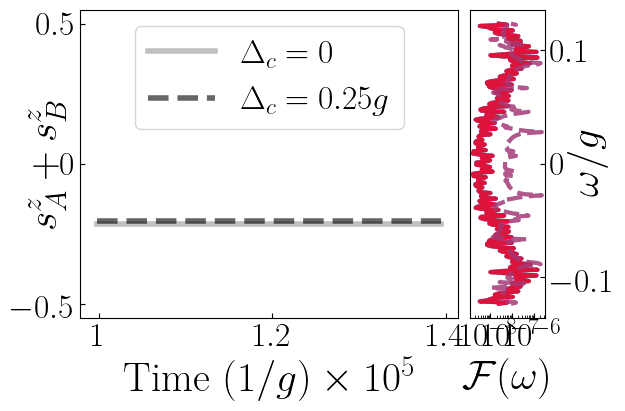

In [114]:
# Create figure with a much narrower right subplot using gridspec_kw
fig, axes = subplots(1, 2, figsize=(6, 4),
                     gridspec_kw=Dict("width_ratios" => [5, 1], "wspace" => 0.050))
ax1, ax2 = axes[1], axes[2]  # ax1: time domain, ax2: frequency domain

cs = ["dodgerblue", "crimson"]
css = ["silver", "black"]
t_steady = t_array[steady_idx]

# Plot time dynamics on left subplot (ax1)
for (i, Δ) in enumerate(delta_vals)
    res = results[Δ]
    
    if Δ == delta_vals[2]
        lsi = "--"
        ai = 0.6
    else
        lsi = "-"
        ai = 1.0
    end
    
    ax1.plot(t_steady[1:100], res[:sz1][1:100], 
            lw=4, c=css[i], ls=lsi, alpha=ai, label=Δ == 0 ? L"$\Delta_c=0$" : L"$\Delta_c=0.25g$")
end

# Set left subplot properties (time domain)
ax1.set_ylim(-1/2-0.05, 1/2 + 0.05)
ax1.set_yticks([-1/2, 0, 1/2])
ax1.set_yticklabels([L"-0.5", L"0", L"0.5"])
ax1.set_xlabel(L"Time $(1/g)\times10^5$")
ax1.set_xticks([10000, 12000,14000], [L"1", L"1.2", L"1.4"])
ax1.set_ylabel(L"$s_A^z + s_B^z$", labelpad=-40)
ax1.legend(loc="upper center")

# Plot frequency spectrum on right subplot (ax2) with flipped axes
for (i, Δ) in enumerate(delta_vals)
    res = results[Δ]
    freq = res[:freq]
    Nhalf = res[:Nhalf]
    pos_range = 2:Nhalf

    # Get the positive frequency data
    freq_pos = freq[pos_range]/g
    amp_sz1_pos = res[:amp_sz1][pos_range]
    amp_sz2_pos = res[:amp_sz2][pos_range]
    
    # Create symmetric data by duplicating to negative frequencies
    freq_sym = [-reverse(freq_pos); freq_pos]
    amp_sz1_sym = [reverse(amp_sz1_pos); amp_sz1_pos]
    amp_sz2_sym = [reverse(amp_sz2_pos); amp_sz2_pos]
    
    if Δ == delta_vals[2]
        lsi = "--"
        ai = 0.6
    else
        lsi = "-"
        ai = 1.0
    end
    
    # Plot with flipped axes: amplitude on x, frequency on y
    ax2.plot(amp_sz1_sym, freq_sym, lw=3, ls=lsi, c=cs[1], alpha=ai)
    ax2.plot(amp_sz2_sym, freq_sym, lw=3, ls=lsi, c=cs[2], alpha=ai)
end

# Set right subplot properties (frequency domain with flipped axes)
ax2.set_xscale("log")  # Log scale for amplitude (now x-axis)
ax2.set_ylabel(L"$\omega/g$", labelpad=-35)
ax2.set_xlabel(L"$\mathcal{F}(\omega)$")
ax2.set_yticks([-0.1, 0, 0.1])
ax2.set_yticklabels([L"-0.1", L"0", L"0.1"])

# Move y-axis to right side
ax2.yaxis.set_label_position("right")
ax2.yaxis.tick_right()


ax1.tick_params(direction="in", which="both")
ax2.tick_params(direction="in", which="both",right=true)
display(fig)
#savefig("../supmat/supmat_Delta_c.pdf", bbox_inches="tight", pad_inches=0.01)
